## 1. Load features and inspect per bearing
This cell loads time domain features for the 2nd test dataset.
One row is one measurement in time.
Each table shows the first 5 rows for one bearing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.features import extract_features

DATA_DIR = 'data/raw/2nd_test/'
df = extract_features(DATA_DIR)
for i in [1, 2, 3, 4]:
    print(f"=== Bearing {i} ===")
    display(df[[c for c in df.columns if f'Bearing_{i}_' in c]].head())

=== Bearing 1 ===


,Bearing_1_RMS,Bearing_1_Kurtosis,Bearing_1_CrestFactor,Bearing_1_Peak,Bearing_1_Skewness,Bearing_1_Std
Time,,,,,,
2004-02-12 10:32:39,0.074179,0.628763,6.120331,0.454,0.083993,0.073475
2004-02-12 10:42:39,0.075382,0.648291,5.147086,0.388,0.052142,0.075338
2004-02-12 10:52:39,0.076230,0.513475,6.598472,0.503,0.032808,0.076189
2004-02-12 11:02:39,0.078724,1.157953,7.723217,0.608,0.041486,0.078691
2004-02-12 11:12:39,0.078474,0.603177,4.982524,0.391,0.028224,0.078437


=== Bearing 2 ===


,Bearing_2_RMS,Bearing_2_Kurtosis,Bearing_2_CrestFactor,Bearing_2_Peak,Bearing_2_Skewness,Bearing_2_Std
Time,,,,,,
2004-02-12 10:32:39,0.090944,0.506801,5.640841,0.513,0.126915,0.090053
2004-02-12 10:42:39,0.093419,0.253014,5.148852,0.481,0.070088,0.093384
2004-02-12 10:52:39,0.093718,0.310789,5.367171,0.503,0.096583,0.093703
2004-02-12 11:02:39,0.092947,0.235341,6.121762,0.569,0.105834,0.092916
2004-02-12 11:12:39,0.095348,0.226309,5.097120,0.486,0.097966,0.095335


=== Bearing 3 ===


,Bearing_3_RMS,Bearing_3_Kurtosis,Bearing_3_CrestFactor,Bearing_3_Peak,Bearing_3_Skewness,Bearing_3_Std
Time,,,,,,
2004-02-12 10:32:39,0.109404,3.213075,9.350652,1.023,0.204840,0.108434
2004-02-12 10:42:39,0.109817,1.395250,6.847735,0.752,-0.023854,0.109790
2004-02-12 10:52:39,0.109861,2.639948,8.492546,0.933,0.056561,0.109849
2004-02-12 11:02:39,0.110667,2.682779,9.180734,1.016,0.033550,0.110622
2004-02-12 11:12:39,0.107506,1.578395,7.171719,0.771,-0.002892,0.107499


=== Bearing 4 ===


,Bearing_4_RMS,Bearing_4_Kurtosis,Bearing_4_CrestFactor,Bearing_4_Peak,Bearing_4_Skewness,Bearing_4_Std
Time,,,,,,
2004-02-12 10:32:39,0.054103,0.065959,4.879539,0.264,-0.022080,0.053166
2004-02-12 10:42:39,0.056101,0.107539,4.438435,0.249,0.001582,0.055973
2004-02-12 10:52:39,0.056145,0.257236,6.305078,0.354,0.070449,0.056037
2004-02-12 11:02:39,0.056807,0.806190,9.241749,0.525,-0.036327,0.056684
2004-02-12 11:12:39,0.056841,0.138954,4.292680,0.244,0.019008,0.056777


## 2. All features over the full timeline

One subplot per feature, all 4 bearings in each.
Flat and low means healthy. A sharp rise means the fault starts.

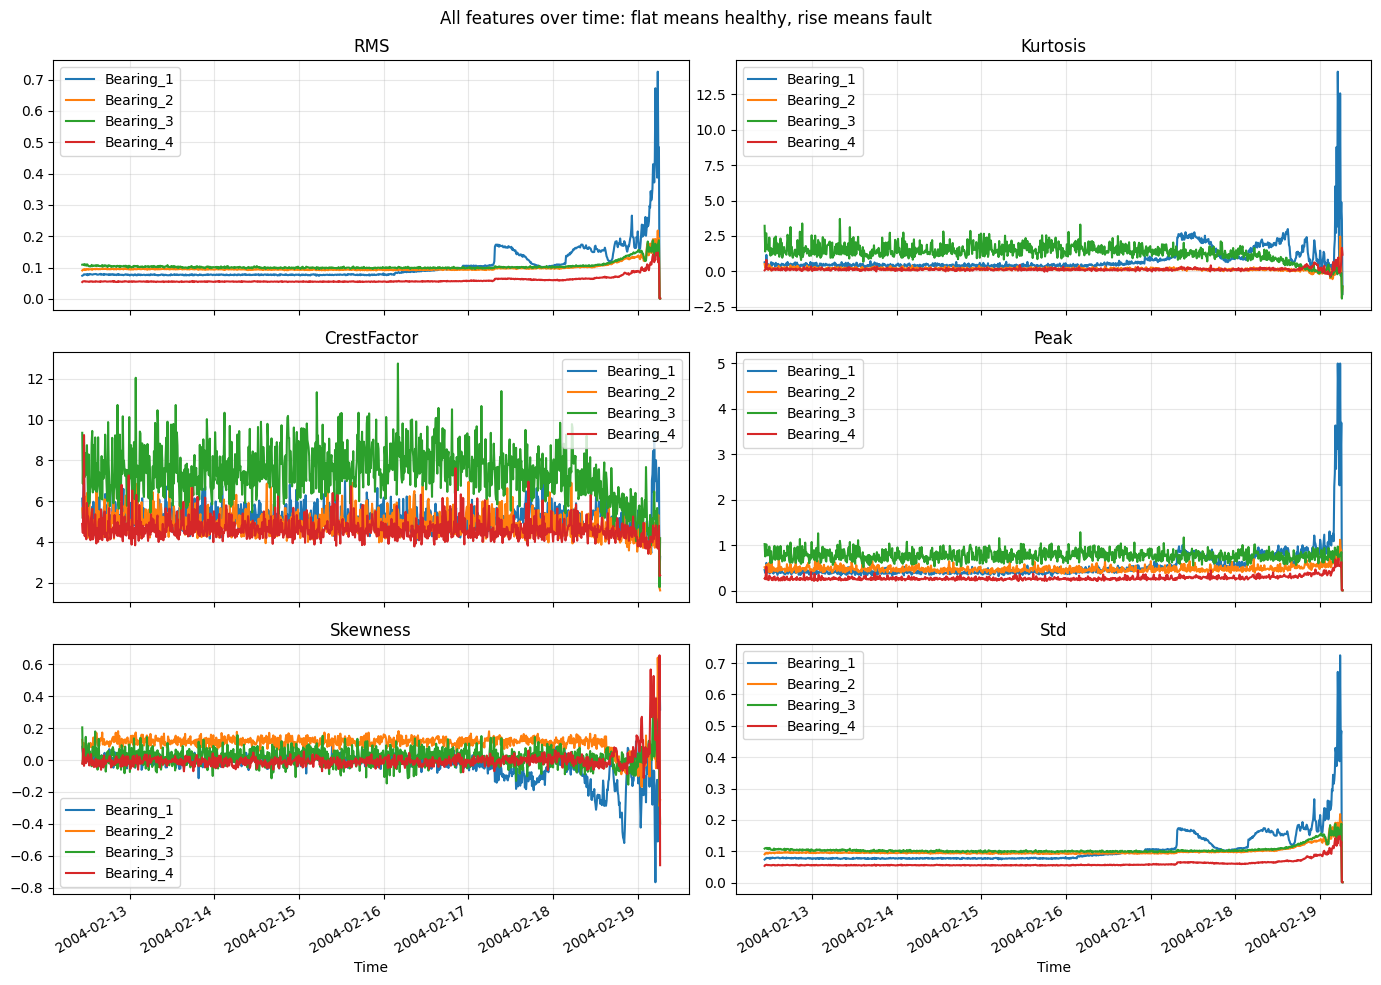

In [2]:
features = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std']
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for ax, feat in zip(axes.flat, features):
    cols = [c for c in df.columns if c.endswith('_' + feat)]
    renamed = {c: c.replace('_' + feat, '') for c in cols}
    df[cols].rename(columns=renamed).plot(ax=ax)
    ax.set_title(feat)
    ax.grid(alpha=0.3)
plt.suptitle('All features over time: flat means healthy, rise means fault')
plt.tight_layout()
plt.show()

## 3. Fault localization: which bearing fails

Compare late against early values per bearing and per feature, no boundary needed.
A healthy channel stays near growth 1. The failed bearing grows on several
independent features at once. Skewness is left out, its healthy baseline sits
near zero so ratios explode.

### How the verdict is computed

1. Take the first 100 rows as the early reference and the last 100 rows as
   the late state.
2. For each bearing and each of RMS, Kurtosis, Peak and Std, divide late
   mean by early mean. That is the growth ratio.
3. Average the four growth ratios per bearing (CrestFactor and Skewness are
   excluded - see note below).
4. The bearing with the highest average growth ratio is printed as faulty.
   Full code lives in `identify_faulty_bearing` in `src/evaluation.py`.

In [3]:
from src.evaluation import identify_faulty_bearing

result = identify_faulty_bearing(df)
display(result['summary'])
print(f"Faulty bearing: {result['faulty_bearing']}")

,rms_growth,kurtosis_growth,crest_factor_growth,peak_growth,std_growth
bearing,,,,,
Bearing_1,2.79,3.64,0.96,2.86,2.79
Bearing_2,1.38,0.06,0.83,1.16,1.38
Bearing_3,1.29,0.10,0.74,0.94,1.29
Bearing_4,1.56,1.51,0.91,1.42,1.56


Faulty bearing: Bearing_1


### Reading the table above

Row by row: RMS and Std almost tripled on Bearing 1 only.
Peak nearly tripled on Bearing 1 only.
Kurtosis more than tripled on Bearing 1 only, the strongest single witness,
which fits an impulsive fault.
CrestFactor sinks below 1 on all bearings, the known late fault signature
where RMS has caught up with Peak.

**Why Skewness is excluded:** its healthy baseline sits near zero (for example
0.03), so late divided by early explodes into numbers like -14 that mean nothing.
It stays in the section 4 plots where its late swinging is visible directly.
For a ratio table it would only add noise, so the table keeps the five features
where division is meaningful.

How to read the values: every number is a quotient, late mean divided by early mean.
Near 1 means late looks like early, no change. Far from 1 means change.
Rows do not share one reading direction, each row has its own logic, so what
counts as bad differs per feature, as explained row by row below.
RMS and Std near 1.3 to 1.6 is normal drift, 2.79 means vibration energy
almost tripled. Peak near 1 means impacts unchanged, 2.86 means impacts
nearly tripled. Kurtosis near 0.1 to 1.5 is calm, 3.64 means heavy spiking
from impacts, the strongest single witness of an impulsive fault.
CrestFactor below 1 on all bearings is the late fault signature,
RMS has caught up with Peak everywhere.
The code prints the bearing with the highest average across the four growing
features, Bearing_1 at 3.02 against 1.51 for the runner up. No extra metric
is invented, the table holds only the five growth features and the winner
is read straight from them.
Documentation agrees (outer race), as confirmation only.

## 4. Faulty bearing in detail

The previous section identified Bearing 1.
Each feature has its own plot because features use different scales.
Look at which feature reacts first when the fault starts.

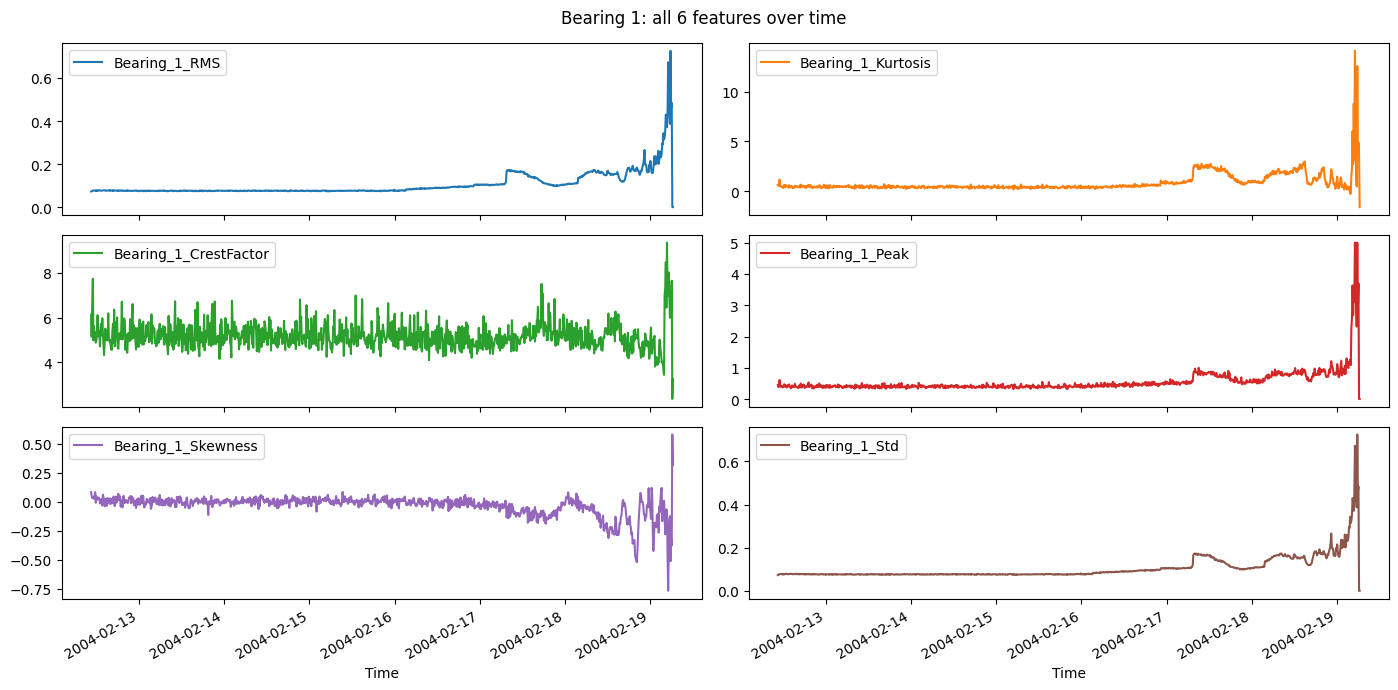

In [4]:
bearing1_cols = [c for c in df.columns if 'Bearing_1_' in c]
df[bearing1_cols].plot(figsize=(14, 7), subplots=True, layout=(3, 2))
plt.suptitle('Bearing 1: all 6 features over time')
plt.tight_layout()
plt.show()

## 5. Compare healthy boundary candidates
Try several boundary dates on Bearing_1_RMS and compare them side by side.
A good boundary keeps FPR low while giving enough healthy samples for training.
If the first alarm moves later when the boundary moves later, the boundary
has swallowed the start of the fault and is too late.

In [5]:
from src.evaluation import compare_boundaries

scores = df['Bearing_1_RMS']
candidates = [
    pd.Timestamp('2004-02-14 12:00:00'),
    pd.Timestamp('2004-02-14 18:00:00'),
    pd.Timestamp('2004-02-15 00:00:00'),
    pd.Timestamp('2004-02-15 06:00:00'),
    pd.Timestamp('2004-02-15 12:00:00'),
    pd.Timestamp('2004-02-16 00:00:00'),
    pd.Timestamp('2004-02-16 06:00:00'),
    pd.Timestamp('2004-02-16 12:00:00'),
    pd.Timestamp('2004-02-16 18:00:00'),
    pd.Timestamp('2004-02-17 00:00:00'),
]
compare_boundaries(scores, candidates)

,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-02-14 12:00:00,297,0.080486,2004-02-16 06:22:39,0.000000
1,2004-02-14 18:00:00,333,0.080461,2004-02-16 06:22:39,0.000000
2,2004-02-15 00:00:00,369,0.080421,2004-02-16 06:22:39,0.000000
3,2004-02-15 06:00:00,405,0.080460,2004-02-16 06:22:39,0.000000
4,2004-02-15 12:00:00,441,0.080361,2004-02-16 06:22:39,0.000000
5,2004-02-16 00:00:00,513,0.080459,2004-02-16 06:22:39,0.001949
6,2004-02-16 06:00:00,549,0.082455,2004-02-16 06:32:39,0.029144
7,2004-02-16 12:00:00,585,0.087362,2004-02-16 12:32:39,0.044444
8,2004-02-16 18:00:00,621,0.092661,2004-02-16 18:32:39,0.027375
9,2004-02-17 00:00:00,657,0.099424,2004-02-17 01:32:39,0.015221


### Reading the table above

- **Rows for 2004-02-14 12:00 through 2004-02-16 00:00** (6 candidates):
  threshold stays flat (~0.0804), first_alarm is identical every time
  (2004-02-16 06:22:39), FPR stays near zero. This means the fault has NOT
  started yet in this range - safe to use as "healthy" training data.
- **Rows from 2004-02-16 06:00 onward**: threshold keeps rising
  (0.082 -> 0.099), and first_alarm keeps shifting later (06:32 -> 12:32 ->
  18:32 -> next day 01:32). This is the signature of contamination: the
  fault has already begun, so including this period as "healthy" trains the
  model to treat early fault symptoms as normal, delaying detection.
- **Conclusion**: the widest safe boundary is 2004-02-16 00:00:00 - the last
  candidate before results start changing.

## 6. Decision: chosen healthy boundary

We choose 2004-02-16 00:00:00 (513 healthy samples) - the widest boundary
that still gives stable results, per the interpretation above.

In [6]:
HEALTHY_BOUNDARY = pd.Timestamp('2004-02-16')
print(f"Chosen healthy boundary: {HEALTHY_BOUNDARY}")

Chosen healthy boundary: 2004-02-16 00:00:00


## 7. Split into healthy / full dataset

Using the boundary chosen above. We further split the healthy period into
a training part (fits the model/scaler) and a validation part (sets the
threshold). This avoids computing the threshold on the same data the model
was fit on, which would bias it optimistically - per advisor feedback.

In [7]:
from src.preprocessing import split_healthy, scale_features, split_train_val

df_healthy = split_healthy(df, HEALTHY_BOUNDARY)
df_healthy_train, df_healthy_val = split_train_val(df_healthy, val_fraction=0.2)

print(f"Healthy total: {len(df_healthy)}")
print(f"Healthy train: {len(df_healthy_train)} ({df_healthy_train.index[0]} to {df_healthy_train.index[-1]})")
print(f"Healthy val:   {len(df_healthy_val)} ({df_healthy_val.index[0]} to {df_healthy_val.index[-1]})")

X_healthy_train, X_all, scaler = scale_features(df_healthy_train, df)
X_healthy_val = scaler.transform(df_healthy_val)
input_dim = X_healthy_train.shape[1]
print(f"Feature dimension: {input_dim}")

Healthy total: 513
Healthy train: 411 (2004-02-12 10:32:39 to 2004-02-15 06:52:39)
Healthy val:   102 (2004-02-15 07:02:39 to 2004-02-15 23:52:39)
Feature dimension: 24


## 8. Classical models

Fit each detector on the TRAINING part of the healthy data only, then
compute its threshold from the held-out VALIDATION part (not seen during
fitting). Score the full timeline and compare first alarm and FPR.

In [8]:
from src.classical_models import (
    fit_isolation_forest, score_isolation_forest,
    fit_one_class_svm, score_one_class_svm,
    fit_lof, score_lof,
    fit_pca, score_pca,
)
from src.evaluation import compute_threshold, first_confirmed_alarm, false_positive_rate
import numpy as np

def evaluate(name, full_scores, val_scores, index):
    val_mean = float(np.mean(val_scores))
    val_std = float(np.std(val_scores))
    print(f"{name}: val_scores mean={val_mean:.5f}  std={val_std:.5f}")

    scores_series = pd.Series(full_scores, index=index)
    threshold = compute_threshold(val_scores, method="mean_std", n_std=3.0)
    print(f"{name}: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")

    is_anomaly = scores_series > threshold
    alarm = first_confirmed_alarm(is_anomaly, window=20)
    train_end = df_healthy_train.index[-1]
    val_end = df_healthy.index[-1]
    fpr_train = float(is_anomaly[index <= train_end].mean())
    fpr_val = float(is_anomaly[(index > train_end) & (index <= val_end)].mean())
    print(f"{name}: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")
    print()
    return {"scores": scores_series, "val_mean": val_mean, "val_std": val_std,
            "threshold": float(threshold), "alarm": alarm,
            "fpr_train": fpr_train, "fpr_val": fpr_val}
classical = [
    ('IsolationForest', fit_isolation_forest, score_isolation_forest),
    ('OneClassSVM', fit_one_class_svm, score_one_class_svm),
    ('LOF', fit_lof, score_lof),
    ('PCA', fit_pca, score_pca),
]

classical_results = {}
for name, fit_fn, score_fn in classical:
    model = fit_fn(X_healthy_train)
    full_scores = score_fn(model, X_all)
    val_scores = score_fn(model, X_healthy_val)
    classical_results[name] = evaluate(name, full_scores, val_scores, df.index)

IsolationForest: val_scores mean=0.43148  std=0.02951
IsolationForest: threshold = 0.43148 + 3*0.02951 = 0.51999
IsolationForest: first_alarm=2004-02-17 10:22:39  fpr_train=0.0316  fpr_val=0.0000 (primary)

OneClassSVM: val_scores mean=-0.11021  std=0.08738
OneClassSVM: threshold = -0.11021 + 3*0.08738 = 0.15192
OneClassSVM: first_alarm=2004-02-16 06:22:39  fpr_train=0.0000  fpr_val=0.0196 (primary)



LOF: val_scores mean=1.07513  std=0.08476
LOF: threshold = 1.07513 + 3*0.08476 = 1.32941
LOF: first_alarm=2004-02-16 06:22:39  fpr_train=0.0292  fpr_val=0.0098 (primary)

PCA: val_scores mean=0.02465  std=0.01916
PCA: threshold = 0.02465 + 3*0.01916 = 0.08212
PCA: first_alarm=2004-02-17 02:52:39  fpr_train=0.0292  fpr_val=0.0196 (primary)



In [9]:
classical_summary_df = pd.DataFrame([{
    'model': name,
    'val_mean': r['val_mean'],
    'val_std': r['val_std'],
    'threshold': r['threshold'],
    'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
    'fpr_train': r['fpr_train'],
    'fpr_val': r['fpr_val'],
} for name, r in classical_results.items()]).sort_values('model').reset_index(drop=True)
display(classical_summary_df.style.format({'val_mean': '{:.5f}', 'val_std': '{:.5f}',
    'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'}))

,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,IsolationForest,0.43148,0.02951,0.51999,2004-02-17 10:22:39,0.0316,0.0000
1,LOF,1.07513,0.08476,1.32941,2004-02-16 06:22:39,0.0292,0.0098
2,OneClassSVM,-0.11021,0.08738,0.15192,2004-02-16 06:22:39,0.0000,0.0196
3,PCA,0.02465,0.01916,0.08212,2004-02-17 02:52:39,0.0292,0.0196


Why two FPR numbers: FPR on the train part alone overestimates quality,
it measures how well the model recognizes data it already saw during fitting
rather than how well it generalizes. fpr_val is the reported metric.

## 9. Joint vs separate training

Same four models, two setups: all 24 features together, or one feature type
at a time across all 4 bearings. The joint row reuses the section 8 results,
nothing is retrained for it. Shows whether the combination beats any single
feature on its own.

In [10]:
def alarm_and_fpr(scores_series, threshold):
    is_anomaly = scores_series > threshold
    alarm = first_confirmed_alarm(is_anomaly, window=20)
    train_end = df_healthy_train.index[-1]
    val_end = df_healthy.index[-1]
    fpr_train = float(is_anomaly[scores_series.index <= train_end].mean())
    fpr_val = float(is_anomaly[(scores_series.index > train_end) & (scores_series.index <= val_end)].mean())
    alarm_str = alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None
    return alarm_str, round(fpr_train, 4), round(fpr_val, 4)

comparison = []
for name, _, _ in classical:
    r = classical_results[name]
    alarm, fpr_train, fpr_val = alarm_and_fpr(r['scores'], r['threshold'])
    comparison.append({'setup': 'all_24', 'model': name, 'alarm': alarm,
                       'fpr_train': fpr_train, 'fpr_val': fpr_val})

feature_types = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std']
for feat in feature_types:
    cols = [c for c in df.columns if c.endswith('_' + feat)]
    Xtr_f, Xa_f, sc_f = scale_features(df_healthy_train[cols], df[cols])
    Xva_f = sc_f.transform(df_healthy_val[cols])
    for name, fit_fn, score_fn in classical:
        model = fit_fn(Xtr_f)
        full_scores = score_fn(model, Xa_f)
        val_scores = score_fn(model, Xva_f)
        threshold = compute_threshold(val_scores, method="mean_std", n_std=3.0)
        alarm, fpr_train, fpr_val = alarm_and_fpr(pd.Series(full_scores, index=df.index), threshold)
        comparison.append({'setup': feat, 'model': name, 'alarm': alarm,
                           'fpr_train': fpr_train, 'fpr_val': fpr_val})

order = ['all_24'] + feature_types
comp_df = pd.DataFrame(comparison)
comp_df['setup'] = pd.Categorical(comp_df['setup'], categories=order, ordered=True)
comp_df = comp_df.sort_values(['setup', 'model']).reset_index(drop=True)
print("First confirmed alarm per setup and model (None = the model never alarmed):")
display(comp_df.pivot_table(index='setup', columns='model', values='alarm', aggfunc='first', observed=True))
print("False positive rate on VALIDATION per setup and model (primary, unseen data):")
display(comp_df.pivot_table(index='setup', columns='model', values='fpr_val', aggfunc='first', observed=True).style.format('{:.4f}'))
print("False positive rate on TRAIN per setup and model (sanity check, seen data):")
display(comp_df.pivot_table(index='setup', columns='model', values='fpr_train', aggfunc='first', observed=True).style.format('{:.4f}'))

First confirmed alarm per setup and model (None = the model never alarmed):


model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 02:52:39
RMS,2004-02-17 05:52:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 07:52:39
Kurtosis,2004-02-17 09:42:39,2004-02-17 05:52:39,2004-02-17 01:32:39,2004-02-17 10:22:39
CrestFactor,NaN,2004-02-19 05:52:39,NaN,NaN
Peak,2004-02-17 10:42:39,2004-02-17 10:12:39,2004-02-17 10:12:39,2004-02-18 09:42:39
Skewness,2004-02-18 20:02:39,2004-02-17 20:42:39,2004-02-18 12:32:39,NaN
Std,2004-02-17 05:52:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 07:02:39


False positive rate on VALIDATION per setup and model (primary, unseen data):


model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,0.0000,0.0098,0.0196,0.0196
RMS,0.0000,0.0098,0.0098,0.0196
Kurtosis,0.0000,0.0196,0.0098,0.0294
CrestFactor,0.0000,0.0196,0.0196,0.0294
Peak,0.0000,0.0196,0.0098,0.0294
Skewness,0.0196,0.0294,0.0196,0.0098
Std,0.0000,0.0098,0.0098,0.0000


False positive rate on TRAIN per setup and model (sanity check, seen data):


model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,0.0316,0.0292,0.0000,0.0292
RMS,0.0097,0.0170,0.0000,0.0073
Kurtosis,0.0341,0.0292,0.0000,0.0316
CrestFactor,0.0170,0.0268,0.0000,0.0243
Peak,0.0170,0.0316,0.0000,0.0268
Skewness,0.0146,0.0243,0.0000,0.0219
Std,0.0097,0.0195,0.0000,0.0438


### Reading the comparison above

No setup wins everywhere, the table must be read per model. SVM and LOF alarm
on 16.02 at 06:22 with all 24 features, and RMS and Std alone match them to the
minute, which confirms those two carry the fault signal on their own.

Kurtosis is a mixed case, not a clear "later" feature: for LOF and SVM it alarms
roughly a day after the joint setup (23h and 19h later respectively), but for
IsolationForest and PCA it actually alarms slightly *earlier* than the joint
setup (40 minutes and 80 minutes earlier). Peak and Skewness are more
consistently late across all four models, by a day or more in most cases.
CrestFactor alone mostly never alarms - three of four models return no
confirmed alarm at all, and the one exception (LOF, firing on 19.02) comes at
the very end of the recorded test.

The honest surprise is IsolationForest: RMS and Std alone beat the joint setup
by almost 5 hours (05:52 against 10:22 on 17.02) and Kurtosis alone by about
40 minutes (09:42 against 10:22).

PCA behaves differently from the other three models when restricted to a
single feature type: with only 4 input columns, `n_components=0.95` keeps all 4
components, so nothing is compressed, validation reconstruction error collapses
close to zero and the resulting threshold becomes extremely tight. This makes the
per-feature PCA alarms harder to trust as a measure of feature quality
specifically - the model is reacting to a near-zero threshold rather than to
a clearly learned "normal" pattern. The joint 24-feature PCA result does not
have this problem, since 12 of 24 components are kept, and its
alarm (17.02 02:52) is the one PCA number used with confidence in this
comparison.

The FPR table tells a different story than the alarm table, and only the
validation column counts: fpr_val uses data the model never saw, fpr_train
is a sanity check. On fpr_val, IsolationForest is cleanest at 0.0000 in 6 of 7
setups, but it pays with the latest alarms. OneClassSVM is no longer the FPR
king at 0.0098 to 0.0196, yet it alarms earliest at 16.02 06:22 wherever the
signal allows. The verdict splits: IsolationForest cries wolf the least,
OneClassSVM balances early alarms with low false rates, making it the strongest
single candidate if only one classical model had to be chosen.

The joint 24-feature setup is NOT always fastest: for IsolationForest, RMS and
Std alone detect the fault up to 5 hours earlier than the combination. But the
combination has a different advantage: it does not depend on LUCKILY picking the
right feature in advance. Had someone decided upfront (without this analysis) to
track only CrestFactor or only Skewness, the model would either miss the fault
entirely (CrestFactor) or catch it days later (Skewness). The combination gives
a solid result with no need to know which feature is "right" in advance. That is
its advantage, not speed. Among the four algorithms, OneClassSVM offers the best
combination of a low false positive rate and a competitive alarm time, making it
the strongest single candidate for this dataset if only one classical model had
to be chosen.

## 10. Visual check: model score vs. threshold over time

Plotting the model's actual anomaly score (not raw RMS) against its
threshold, to visually confirm where the alarm fires relative to the
overall shape of the signal.

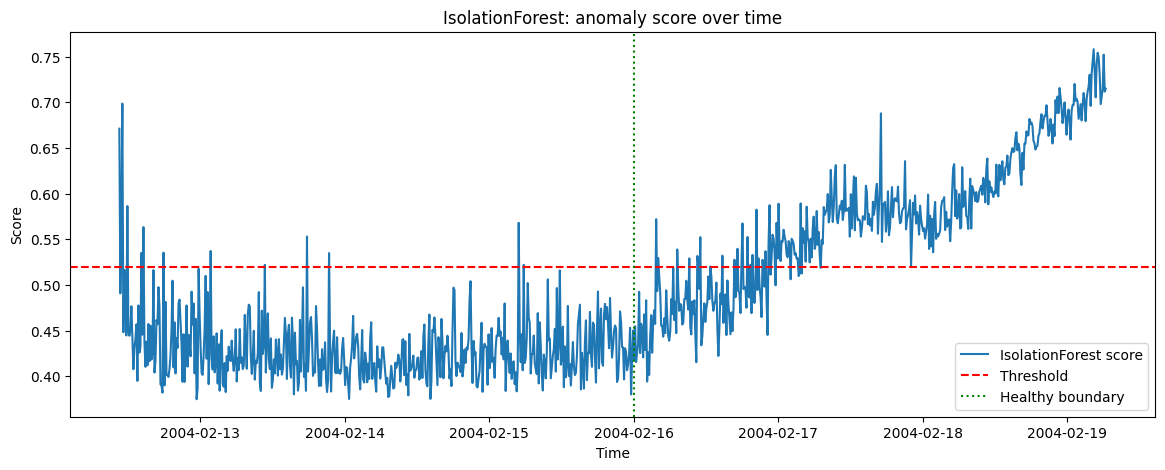

In [11]:
import matplotlib.pyplot as plt

name_to_check = "IsolationForest"
res_to_plot = classical_results[name_to_check]
scores_series, threshold = res_to_plot['scores'], res_to_plot['threshold']

plt.figure(figsize=(14, 5))
plt.plot(scores_series.index, scores_series.values, label=f"{name_to_check} score")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.axvline(HEALTHY_BOUNDARY, color="green", linestyle=":", label="Healthy boundary")
plt.legend()
plt.title(f"{name_to_check}: anomaly score over time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.show()

## 11. Boundary sensitivity check

Same procedure as sections 7 and 8, repeated for boundaries shifted around
the chosen HEALTHY_BOUNDARY. The chosen boundary stays official, this only
checks how sensitive first_alarm and FPR are to that decision.

First confirmed alarm per boundary and model:


model,IsolationForest,LOF,OneClassSVM,PCA
boundary_label,,,,
-12h,2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 23:22:39
-6h,2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 03:02:39
chosen (0h),2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 02:52:39
+6h,2004-02-17 10:22:39,2004-02-16 09:42:39,NaN,2004-02-17 07:02:39
+12h,2004-02-18 05:02:39,2004-02-16 23:22:39,NaN,2004-02-17 08:22:39


Validation FPR per boundary and model:


model,IsolationForest,LOF,OneClassSVM,PCA
boundary_label,,,,
-12h,0.0114,0.0227,0.0114,0.0227
-6h,0.0105,0.0316,0.0211,0.0105
chosen (0h),0.0000,0.0098,0.0196,0.0196
+6h,0.0092,0.0183,0.0000,0.0092
+12h,0.0000,0.0000,0.0000,0.0171


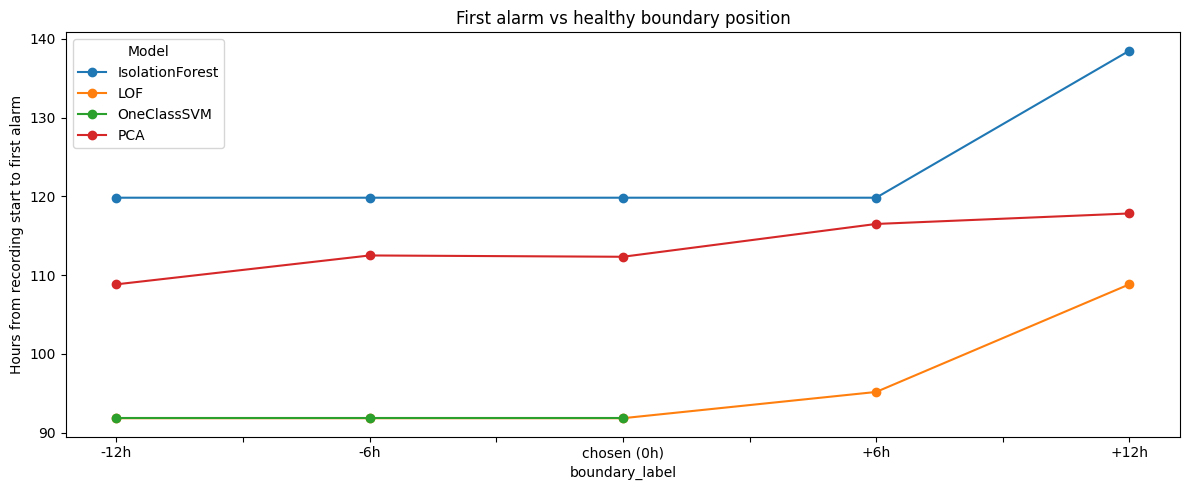

In [12]:
boundary_candidates = {
    '-12h': HEALTHY_BOUNDARY - pd.Timedelta(hours=12),
    '-6h': HEALTHY_BOUNDARY - pd.Timedelta(hours=6),
    'chosen (0h)': HEALTHY_BOUNDARY,
    '+6h': HEALTHY_BOUNDARY + pd.Timedelta(hours=6),
    '+12h': HEALTHY_BOUNDARY + pd.Timedelta(hours=12),
}

sens_rows = []
for label, b in boundary_candidates.items():
    df_h = split_healthy(df, b)
    df_tr, df_va = split_train_val(df_h, val_fraction=0.2)
    Xtr, Xa_, sc_ = scale_features(df_tr, df)
    Xva_ = sc_.transform(df_va)
    train_end, val_end = df_tr.index[-1], df_h.index[-1]
    for name, fit_fn, score_fn in classical:
        model = fit_fn(Xtr)
        full = pd.Series(score_fn(model, Xa_), index=df.index)
        val = score_fn(model, Xva_)
        threshold = compute_threshold(val, method="mean_std", n_std=3.0)
        is_an = full > threshold
        alarm = first_confirmed_alarm(is_an, window=20)
        fpr_v = float(is_an[(full.index > train_end) & (full.index <= val_end)].mean())
        sens_rows.append({'boundary_label': label, 'model': name,
                         'alarm': (alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None),
                         'fpr': round(fpr_v, 4)})

order12 = ['-12h', '-6h', 'chosen (0h)', '+6h', '+12h']
sens_df = pd.DataFrame(sens_rows)
sens_df['boundary_label'] = pd.Categorical(sens_df['boundary_label'], categories=order12, ordered=True)
sens_df = sens_df.sort_values(['boundary_label', 'model']).reset_index(drop=True)
print("First confirmed alarm per boundary and model:")
display(sens_df.pivot_table(index='boundary_label', columns='model', values='alarm', aggfunc='first', observed=True))
print("Validation FPR per boundary and model:")
display(sens_df.pivot_table(index='boundary_label', columns='model', values='fpr', aggfunc='first', observed=True).style.format('{:.4f}'))
plot_sens = sens_df.copy()
plot_sens['alarm_h'] = (pd.to_datetime(plot_sens['alarm']) - df.index[0]).dt.total_seconds() / 3600
plot_sens.pivot_table(index='boundary_label', columns='model', values='alarm_h', observed=True).plot(kind='line', marker='o', figsize=(12, 5))
plt.ylabel('Hours from recording start to first alarm')
plt.title('First alarm vs healthy boundary position')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### Reading the sensitivity check

Each model reacts very differently to the same 6-24 hour shift in the
healthy/full boundary - this matters more than which model "wins" on the
chosen boundary alone.

- **IsolationForest**: identical alarm (2004-02-17 10:22:39) from -12h
  through +6h - fully stable. Only at +12h does it break, jumping ~19 hours
  later. Note the FPR actually drops to 0.0000 at +12h - this looks like an
  improvement but is not: the threshold has been pushed so high (by training
  on data that already contains early fault symptoms) that almost nothing
  crosses it anymore, healthy or not. A falling FPR paired with a much later
  alarm is a red flag, not good news.

- **LOF**: degrades gradually - exact alarm through 0h, then slips by about
  3.5 hours at +6h and 17 hours at +12h. No sudden break, just a smooth
  delay. This is the "softest" failure mode of the four.

- **OneClassSVM**: the most fragile by far. It matches the other models
  exactly on the early side (-12h to 0h), but at +6h and +12h it stops
  alarming entirely (first_alarm = NaN) - including through the catastrophic
  end-of-life spike visible in section 2's plot. This is not a delay, it is
  a silent, complete failure: once early fault symptoms are folded into
  "healthy" training data, the learned boundary widens so much that even
  the worst-case failure no longer looks anomalous. A 6-hour boundary error
  is enough to make this specific model produce zero alarms for the rest
  of the dataset.

- **PCA**: the most robust - drifts smoothly by about 9 hours total across
  the entire -12h to +12h range, no sharp breaks, no missed alarms.

Validation FPR stays low everywhere (0.0000-0.0316) regardless of boundary,
which is precisely why FPR alone cannot be used to judge these models here -
a model can have a great FPR while having silently stopped detecting
anything (see OneClassSVM above). First-alarm timing and whether an alarm
fires at all are the metrics that actually reveal fragility.

**Conclusion**: this check does not prove 2004-02-16 is the objectively
correct boundary (there is no independent ground truth for the exact fault
onset), but it shows the chosen boundary sits in a genuinely stable region
for every model on the early side. It also surfaces a finding independent
of boundary choice: OneClassSVM is far less robust than the other three
detectors to this specific methodological decision, which is itself worth
reporting as a comparison dimension - not just detection speed, but
robustness to how the healthy period is defined.